In [2]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np

In [3]:
df_full = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [4]:
df = df_full.copy()

In [5]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [7]:
#df_X[df_X["status"]]

In [8]:
df_X["status"].unique()

array([200, 307, 404])

In [9]:
df_X[df_X["status"] == 307]["page"].unique()

array(['Thumbs Up', 'Thumbs Down', 'Add Friend', 'Logout',
       'Submit Downgrade', 'Submit Upgrade', 'Save Settings'],
      dtype=object)

In [24]:
df_a = df_X.groupby(["userId","status"]).size().reset_index(name="num")

In [43]:
df_a["status"] = df_a["status"].apply(str)

In [44]:
df_b = df_a.pivot(index="userId", columns="status", values="num")

In [49]:
df_b["404"] = df_b["404"].fillna(0.0)
df_b["307"] = df_b["307"].fillna(0.0)
df_b["200"] = df_b["200"].fillna(0.0)

In [50]:
df_b

status,200,307,404
userId,,,
1000035,818.0,97.0,0.0
1000103,63.0,5.0,0.0
1000164,420.0,28.0,0.0
1000168,387.0,58.0,0.0
1000182,319.0,30.0,0.0
...,...,...,...
1999241,282.0,22.0,0.0
1999382,34.0,4.0,0.0
1999781,2311.0,177.0,3.0


In [51]:
df_c = df_b.merge(df_y, on = "userId")

In [52]:
df_c

,userId,200,307,404,Cancellation Confirmation
0,1000035,818.0,97.0,0.0,0
1,1000103,63.0,5.0,0.0,0
2,1000164,420.0,28.0,0.0,0
3,1000168,387.0,58.0,0.0,0
4,1000182,319.0,30.0,0.0,0
...,...,...,...,...,...
15428,1999241,282.0,22.0,0.0,0
15429,1999382,34.0,4.0,0.0,0
15430,1999781,2311.0,177.0,3.0,0
15431,1999848,523.0,58.0,1.0,0


In [53]:
import seaborn as sns

<Axes: xlabel='404', ylabel='Count'>

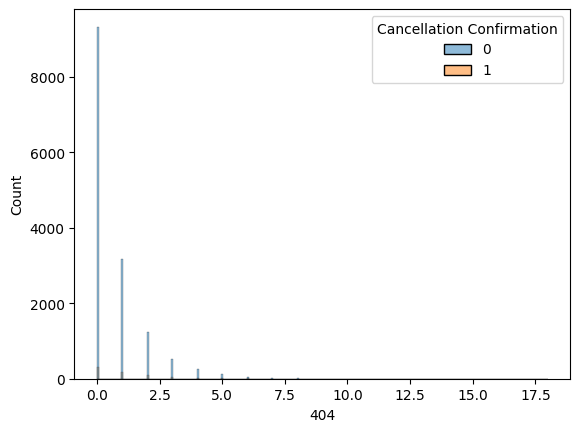

In [56]:
sns.histplot(df_c, x = "404", hue="Cancellation Confirmation")

In [ ]:
df_b

,userId,status,num,Cancellation Confirmation
0,1000035,200,818,0
1,1000035,307,97,0
2,1000103,200,63,0
3,1000103,307,5,0
4,1000164,200,420,0
...,...,...,...,...
36405,1999848,200,523,0
36406,1999848,307,58,0
36407,1999848,404,1,0
36408,1999905,200,285,0


In [ ]:
import seaborn as sns

In [58]:
sns.boxplot(df_b[df_b["status"] == "404"], x = "Cancellation Confirmation", y = "num")

KeyError: 'status'